# Self-Organizing Maps (2D grid)

In [1]:
'''

SOM : Self-organizing Maps (2D grid)

Date: 1/7/2022
Author: Yoonsuck Choe

'''


'\n\nSOM : Self-organizing Maps (2D grid)\n\nDate: 1/7/2022\nAuthor: Yoonsuck Choe\n\n'

# Utility Code: weight initialization and plotting

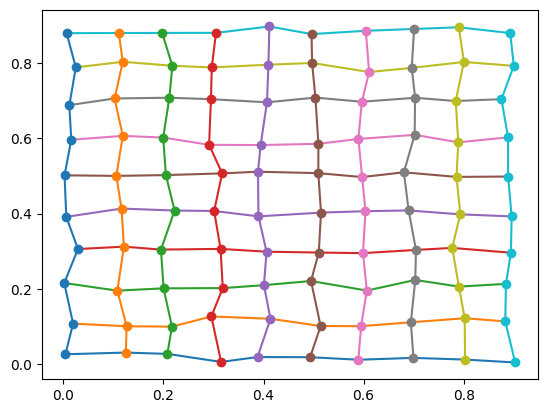

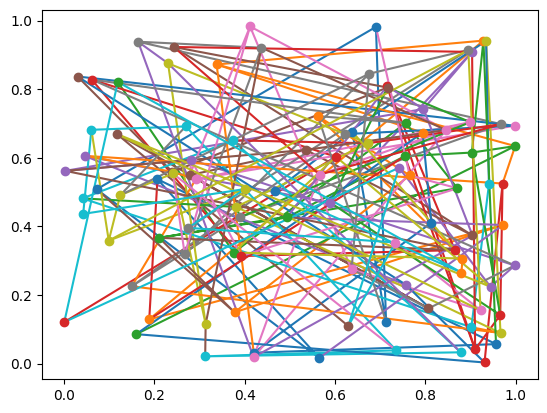

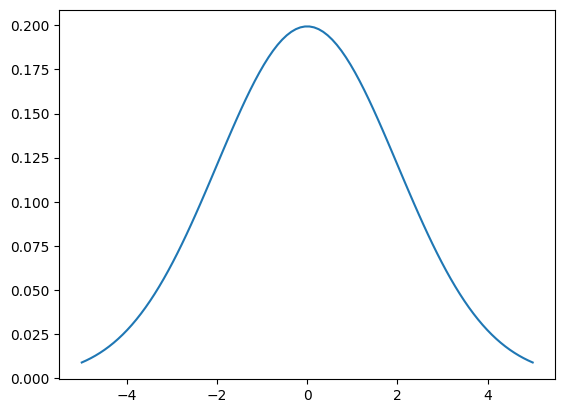

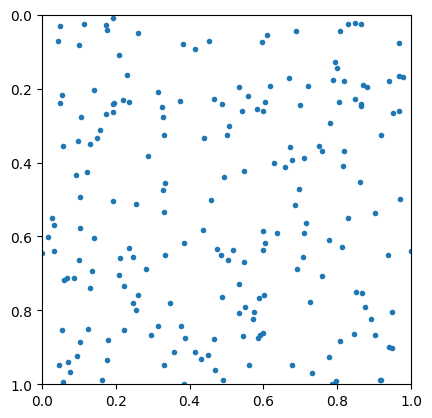

In [2]:
'''

Utility code : weight initialization, plotting, etc.

'''


import math
import numpy as np
import matplotlib.pyplot as plt

#---------------------------------------------------------------------
def som_w_init(n,r):
#---------------------------------------------------------------------
  '''
  W_init : init weight matrix
   arguments:
      n : SOM grid dimension (n x n grid)
      r : randomness (0<= r <= 1)
   returns: two matrices [W_0, W_1] that contain w0 and w1 values, each as an n x n matrix .
  '''

  a_idx = np.array(range(0,n))
  a_ones = np.ones(n)

  # Use outer product to generate the matrices

  # W0 =
  # [ 1 , * [ 1, 2, 3, 4 ]  = [[ 1, 2, 3, 4],
  #   1 ,                      [ 1, 2, 3, 4],
  #   1 ,                      [ 1, 2, 3, 4],
  #   1 ]                      [ 1, 2, 3, 4]]
  W0 = np.outer(a_ones,a_idx)/n

  # W1 is simply a transpose of W0
  W1 = np.transpose(W0)

  # Add noise
  W0 = W0*(1-r)+(np.random.rand(n,n)*r)
  W1 = W1*(1-r)+(np.random.rand(n,n)*r)

  return [W0,W1]



#---------------------------------------------------------------------
def som_w_plot(W0, W1):
#---------------------------------------------------------------------
  '''
  W_plot : plot SOM map
  arguments:
    W0 : w0 values
    W1 : w1 values
  '''
  plt.plot(W0,W1,"-",np.transpose(W0),np.transpose(W1),"-")
  plt.plot(W0,W1,"o")



#---------------------------------------------------------------------
def som_neigh(u,v,s):
#---------------------------------------------------------------------
  '''
  som_neigh : neighborhood function

  arguments:
    u : np.array (1 x 2), of best matching unit's location
    v : np.array (1 x 2)
    s : std of gaussian neighbor (~ neighborhood radius)
  returns: neighbordhood function value
  '''

  # Euclidean distance
  dist = np.linalg.norm(u-v)

  # Gaussian
  g = 1.0/(s * math.sqrt(2*math.pi)) * math.exp(-dist*dist/(2*s*s))

  return g


#---------------------------------------------------------------------
def som_bmu(W0, W1, x):
#---------------------------------------------------------------------
  '''
  som_bmu : find bestmatching unit for input x, given weights W0 and W1

  arguments:
    W0 : w_0 matrix (for 2D grid)
    W1 : w_1 matrix
    x  : 2D input vector
  returns:
    bmu : coordinate or nest matching unit
  '''

  diff0 = W0-x[0]
  diff1 = W1-x[1]
  dist = np.multiply(diff0,diff0) + np.multiply(diff1,diff1)

  # --- calculate best matching unit index
  idx=dist.argmin()
  bmu0 = int(np.floor(idx/n))  # row
  bmu1 = int(np.mod(idx,n))    # col
  bmu = np.array([bmu0, bmu1])

  return bmu


#---------------------------------------------------------------------
def som_plot_inp(inp):
#---------------------------------------------------------------------
  '''
  som_plot_inp : plot input samples

  arguments:
    inp : input matrix (n x 2), n samples
  '''

  fig = plt.figure()
  ax = fig.add_subplot()
  ax.set_aspect('equal')
  ax.set_xlim([0,1])
  ax.set_ylim([0,1])
  ax.invert_yaxis()
  ax.plot(inp[:,0],inp[:,1],".")


#---------------------------------------------------------------------
def som_plot_model(k,x,bmu,W0,W1,n,neigh_mat,alpha,radius):
#---------------------------------------------------------------------
  '''
  som_plot_model: plots the grid and various information about the current status of the model

  argument:
    k         : current iteration #
    x         : input vector (1x2)
    bmu       : best matching unit coordinates [row, col]
    W0        : w_0 matrix
    W1        : w_1 matrix
    n         : n x n grid
    neigh_mat : n x n matrix of neighborhood function value for current BMU location
    alpha     : current learning rate
    radius    : current neighborhood radius
  '''

  plt.figure()
  plt.imshow(neigh_mat)

  # plot grid (input space)
  som_w_plot(W0*n,W1*n)

  # plot input (input space)
  plt.plot(x[0]*n,x[1]*n,"r*",markersize=15)

  # plot BMU location (grid space)
  plt.plot(bmu[1],bmu[0],"go",markersize=7) # bmu0 is row, bmu1 is col, so bmu0 = y, bmu1 = x

  # mark BMU on grid (input space)
  plt.plot(W0[bmu[0],bmu[1]]*n,W1[bmu[0],bmu[1]]*n,"wx",markersize=20) # bmu0 is row, bmu1 is col, so bmu0 = y, bmu1 = x



  print("[Iter "+str(k)+"]\t Input = "+str(x)+";\t alpha ="+str(alpha)+";\t radius ="+str(radius))


#---------------------------------------------------------------------
# 1. TEST weight init and plotting
#---------------------------------------------------------------------
[W0,W1] = som_w_init(10,0.03)
plt.figure()
som_w_plot(W0,W1)


[W0,W1] = som_w_init(10,1.0)
plt.figure()
som_w_plot(W0,W1)

#---------------------------------------------------------------------
# 2. TEST neighborhood function
#---------------------------------------------------------------------
x = np.linspace(-5,5,100)
y = np.zeros(x.size)
std = 2.0
for i in range(0,y.size):
  y[i] = som_neigh(np.array([0,0]),np.array([x[i],0]),std)

plt.figure()
plt.plot(x,y)

# 3. TEST input plotting
inp = np.random.rand(200, 2)
som_plot_inp(inp)


# SOM: Main algorithm

[Iter 1]	 Input = [0.98616628 0.4864897 ];	 alpha =0.29985;	 radius =3.997
[Iter 201]	 Input = [0.96221578 0.82713295];	 alpha =0.27130871473362184;	 radius =3.4400561763571558
[Iter 401]	 Input = [0.97993425 0.69504348];	 alpha =0.24548413770355118;	 radius =2.9607171619947485
[Iter 601]	 Input = [0.56457806 0.47709308];	 alpha =0.22211767846537234;	 radius =2.5481694669919115
[Iter 801]	 Input = [0.1016407  0.88604486];	 alpha =0.200975360560467;	 radius =2.1931063581011365
[Iter 1001]	 Input = [0.74634925 0.70640447];	 alpha =0.18184547862860267;	 radius =1.8875179065784258
[Iter 1201]	 Input = [0.89468746 0.03323109];	 alpha =0.1645364785287525;	 radius =1.6245102908455957
[Iter 1401]	 Input = [0.91148868 0.83274181];	 alpha =0.14887503924106044;	 radius =1.3981502776029902
[Iter 1601]	 Input = [0.93507369 0.20777427];	 alpha =0.13470433734337026;	 radius =1.2033313730156714
[Iter 1801]	 Input = [0.04574448 0.40320253];	 alpha =0.12188247668392202;	 radius =1.0356586244550656


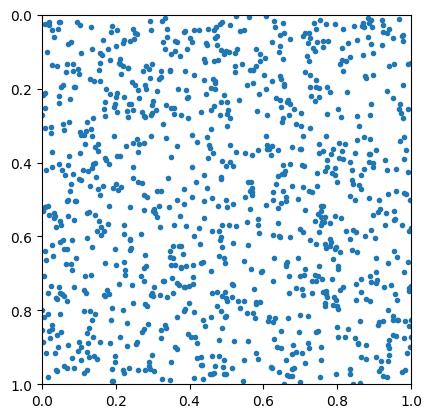

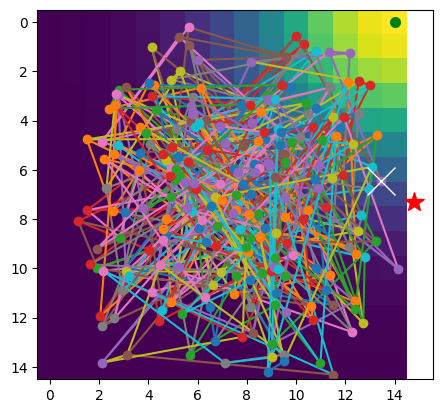

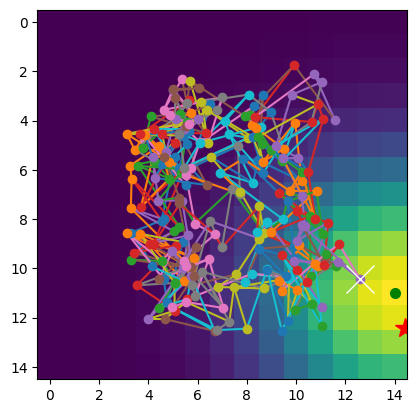

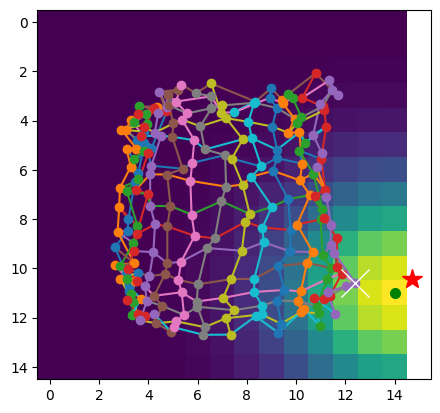

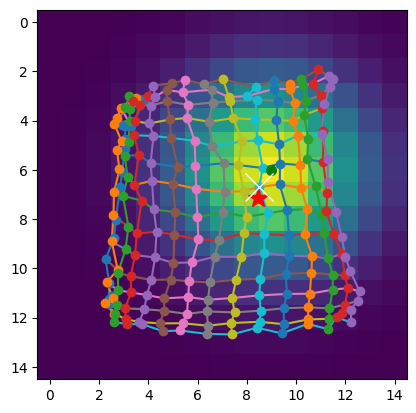

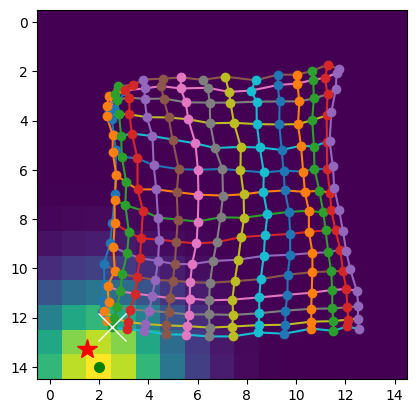

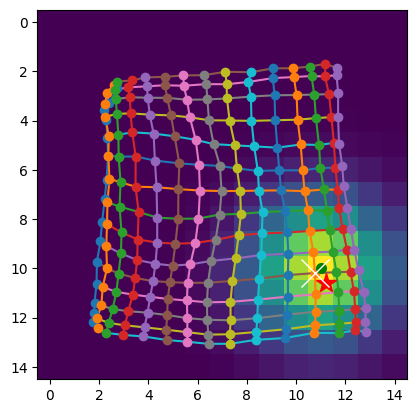

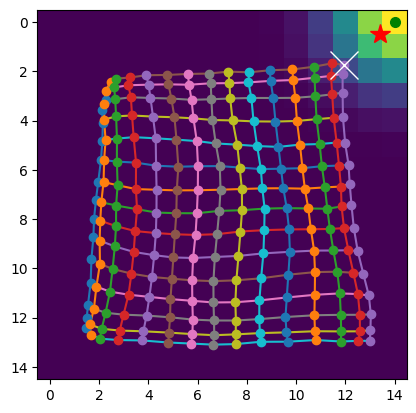

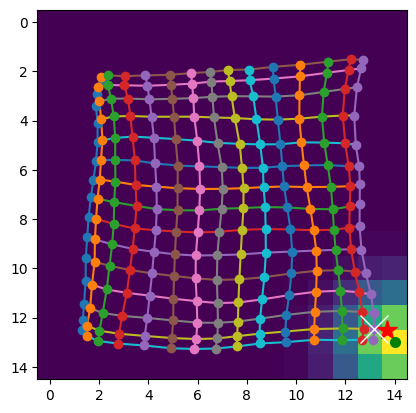

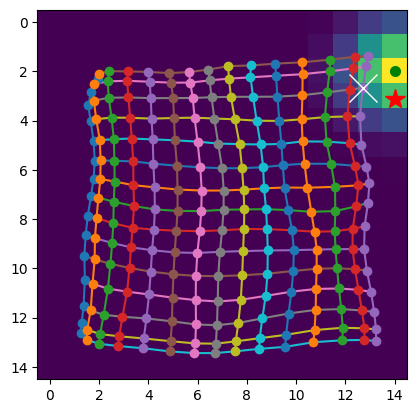

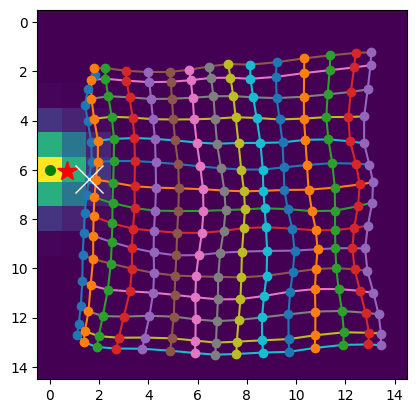

In [3]:
'''
SOM Algorithm
'''

#---------------------------------------------------------------------
def som(n, inp, alpha, radius, alpha_reduce_rate, radius_reduce_rate, w_rand, num_loop):
#---------------------------------------------------------------------
  '''
  SOM with n x n grid

  arguments:
    n : grid size (n x n)
    inp : input data (m x 2), m 2D samples.
    alpha = 0.3      # initial learning rate and typical value
    radius = 4.0     # initial neighborhood radius
    alpha_reduce_rate = 1   # alpha reduction rate (>1)
    radius_reduce_rate = 2  # neighborhood radius reduction rate (>1)
    w_rand = 0.7     # weight setup randomness
    num_loop = 2000  # number of iterations to train
  '''

  num_inp = inp[:,0].size

  # 1. init weights
  [W0,W1] = som_w_init(n, w_rand)

  # 2. loop

  for k in range(1,num_loop):

    # 2.1 randomly draw input from input set
    # num_inp = 2 : for debugging
    inp_idx = np.random.randint(num_inp)
    x = inp[inp_idx]

    # 2.2 find best matching unit
    bmu = som_bmu(W0, W1, x)

    # 2.3 update weights

    neigh_mat = np.zeros([n,n]) # for plotting

    for i in range(0,n): # row
      for j in range(0,n): # col
        loc = np.array([i,j])
        neigh_val = som_neigh(bmu,loc,radius)
        neigh_mat[i,j] = neigh_val

        W0[i,j] = W0[i,j] + alpha * neigh_val * (x[0]-W0[i,j])
        W1[i,j] = W1[i,j] + alpha * neigh_val * (x[1]-W1[i,j])

    # 2.4. Update alpha and neighborhood radius
    alpha = alpha * (1-1/(num_loop/alpha_reduce_rate))
    radius = radius * (1-1/(num_loop/radius_reduce_rate))

    # 2.5 DEBUG & plotting
    if np.mod(k,np.floor(num_loop/10)) == 1:
      som_plot_model(k,x,bmu,W0,W1,n,neigh_mat,alpha,radius)




##################################
# TEST
##################################

# config
n = 15        # n x n grid
num_inp = 1000  # total input samples
test_select = 1

# set up input
if (test_select == 1):
  # 1. random
  test_inp = np.random.rand(num_inp, 2)
elif (test_select==2):
  # 2. gaussian
  test_inp = (np.random.normal(0,5,[num_inp,2]))
  test_inp = (test_inp-test_inp.min())/(test_inp.max()-test_inp.min())
elif (test_select==3):
  # 3. hole in the middle
  test_inp = np.random.rand(num_inp, 2)
  test_inp = test_inp[np.multiply(test_inp[:,0]-0.5,test_inp[:,0]-0.5) + np.multiply(test_inp[:,1]-0.5,test_inp[:,1]-0.5)  > 0.1,:]

# plot input
som_plot_inp(test_inp)

# Run SOM
'''
Example parameters:
alpha = 0.3      # initial learning rate
radius = 4.0     # initial neighborhood radius
alpha_reduce_rate = 1   # alpha reduction rate (>1)
radius_reduce_rate = 2  # neighborhood radius reduction rate (>1)
w_rand = 0.7     # weight setup randomness
num_loop = 2000  # number of iterations to train
'''
som(n, test_inp, alpha=0.3, radius=4.0, alpha_reduce_rate=1, radius_reduce_rate=1.5, w_rand=0.7, num_loop=2000)

In [4]:
# more tests
# som(n, test_inp, alpha=0.3, radius=7.0, alpha_reduce_rate=0.2, radius_reduce_rate=0.8, w_rand=0.7, num_loop=2000)

In [5]:
%history

'''

SOM : Self-organizing Maps (2D grid)

Date: 1/7/2022
Author: Yoonsuck Choe

'''
'''

Utility code : weight initialization, plotting, etc.

'''


import math
import numpy as np
import matplotlib.pyplot as plt

#---------------------------------------------------------------------
def som_w_init(n,r):
#---------------------------------------------------------------------
  '''
  W_init : init weight matrix
   arguments:
      n : SOM grid dimension (n x n grid)
      r : randomness (0<= r <= 1)
   returns: two matrices [W_0, W_1] that contain w0 and w1 values, each as an n x n matrix .
  '''

  a_idx = np.array(range(0,n))
  a_ones = np.ones(n)

  # Use outer product to generate the matrices

  # W0 =
  # [ 1 , * [ 1, 2, 3, 4 ]  = [[ 1, 2, 3, 4],
  #   1 ,                      [ 1, 2, 3, 4],
  #   1 ,                      [ 1, 2, 3, 4],
  #   1 ]                      [ 1, 2, 3, 4]]
  W0 = np.outer(a_ones,a_idx)/n

  # W1 is simply a transpose of W0
  W1 = np.transpose(W0)

  # Add n